
1. DATA   [0 dtk]
Jumlah baris : 1,500,000 | prediktor: 30 | respons: Y
Data latih   : 1,200,000 (80% baris awal) | Data uji: 300,000 (20% baris akhir)
count    1.500000e+06
mean     4.992300e+00
std      6.339100e+00
min     -2.648830e+01
25%      7.240000e-01
50%      4.367400e+00
75%      8.534700e+00
max      1.006869e+02

2. MODEL OLS AWAL (dasar uji asumsi)   [6 dtk]
R2 = 0.1866 | Adj R2 = 0.1866 | p-value uji F = 0

3. UJI NORMALITAS SISAAN (H0: sisaan normal)   [8 dtk]
Skewness = 1.1429 | Kurtosis = 6.6931 (normal: 0 dan 3)
Jarque-Bera              stat =   943,170.8518 | p = 0 | TOLAK H0
   -> Sisaan tidak normal.
Shapiro-Wilk (n=5000)    stat =         0.9486 | p = 1.132e-38 | TOLAK H0
   -> Sisaan tidak normal.
Catatan: n sangat besar membuat uji formal sensitif; lihat juga QQ-plot, skewness, kurtosis.


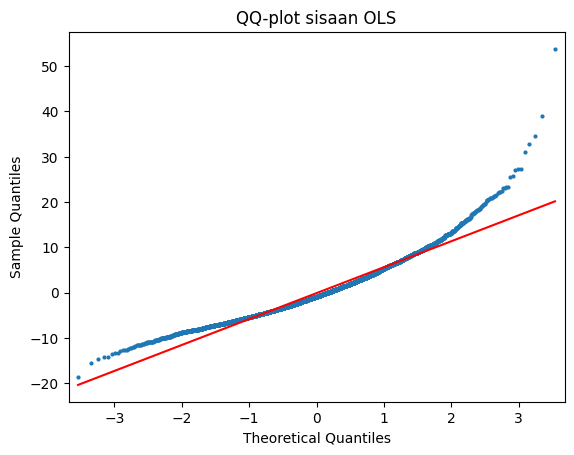


4. UJI MULTIKOLINEARITAS (VIF > 10 = serius)   [8 dtk]
X28    334.17
X29    329.22
X27    298.66
X26    289.92
X11    202.25
X1     139.64
X12    133.25
X6      94.53
X2      82.13
X19     77.00
X24     76.39
X21     73.26
X25     59.08
X20     59.01
X16     57.13
X22     55.47
X7      54.63
X17     53.06
X13     45.75
X23     36.12
X3      33.23
X18     23.28
X8      21.72
X4      17.03
X14     17.01
X9      13.52
X5      10.03
X15      9.12
X10      7.60
X30      5.00
Variabel VIF > 10: 27 | VIF > 5: 30 (dari 30)

5. UJI HETEROSKEDASTISITAS (H0: varians sisaan konstan)   [8 dtk]
Breusch-Pagan            stat =        31.2176 | p = 0.4048 | GAGAL TOLAK H0
   -> Varians sisaan konstan.
White (sampel 20.000)    stat =     1,286.0479 | p = 1.125e-71 | TOLAK H0
   -> Varians sisaan tidak konstan.


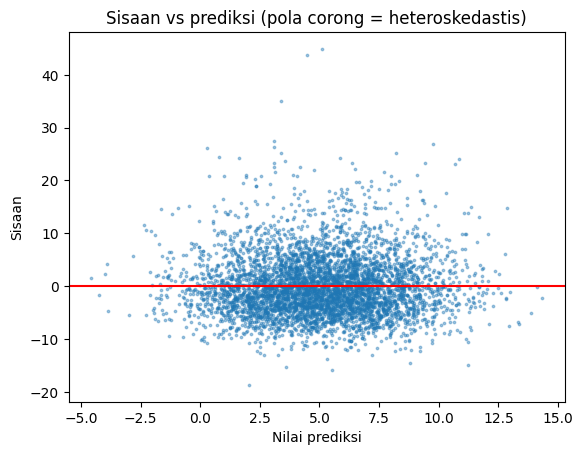


6. UJI AUTOKORELASI SISAAN (H0: tidak ada autokorelasi)   [12 dtk]
Durbin-Watson = 0.6000 (2 = tidak ada, <2 positif, >2 negatif) | rho lag-1 = 0.7000
Breusch-Godfrey (5 lag)  stat =   587,984.5196 | p = 0 | TOLAK H0
   -> Ada autokorelasi.

7. PEMODELAN   [15 dtk]
OLS   : selesai

Persamaan OLS:
Y = 4.9930 + 3.0106*X1 - 0.0185*X2 - 0.0004*X3
    - 2.5072*X4 + 0.0139*X5 + 1.8112*X6 - 0.0345*X7
    + 0.0131*X8 - 1.2173*X9 + 0.0279*X10 + 2.2016*X11
    - 0.0105*X12 + 0.0117*X13 - 0.0116*X14 - 1.4909*X15
    + 0.0054*X16 + 1.4355*X17 - 0.0091*X18 - 0.7626*X19
    - 0.0690*X20 - 0.0905*X21 + 0.0548*X22 + 1.0479*X23
    - 0.0754*X24 + 0.0621*X25 - 1.7905*X26 + 0.2253*X27
    - 0.1763*X28 + 0.1525*X29 + 0.4774*X30

WLS   : selesai

Persamaan WLS:
Y = 4.9930 + 3.0104*X1 - 0.0181*X2 - 0.0009*X3
    - 2.5074*X4 + 0.0145*X5 + 1.8107*X6 - 0.0335*X7
    + 0.0129*X8 - 1.2175*X9 + 0.0275*X10 + 2.2025*X11
    - 0.0114*X12 + 0.0118*X13 - 0.0118*X14 - 1.4910*X15
    + 0.0053*X16 + 1.4356*X17 - 0.0089*

In [5]:
import time
import warnings
import functools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import RidgeCV
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_breusch_godfrey

warnings.filterwarnings("ignore")
print = functools.partial(print, flush=True)

FILE = "raw_data_simulasi.txt"
NROWS = None          # isi angka (mis. 200000) untuk uji coba cepat
ALPHA = 0.05
XCOLS = [f"X{i}" for i in range(1, 31)]
t0 = time.time()
rng = np.random.default_rng(42)


def bagian(judul):
    print(f"\n{'=' * 70}\n{judul}   [{time.time() - t0:.0f} dtk]\n{'=' * 70}")


def uji(nama, stat, p, tolak, gagal):
    keputusan = "TOLAK H0" if p < ALPHA else "GAGAL TOLAK H0"
    print(f"{nama:<24} stat = {stat:>14,.4f} | p = {p:.4g} | {keputusan}")
    print(f"   -> {tolak if p < ALPHA else gagal}")


def persamaan(nama, b):
    suku = [f"{b[0]:.4f}"] + [f"{'+' if v >= 0 else '-'} {abs(v):.4f}*{x}" for v, x in zip(b[1:], XCOLS)]
    baris = [" ".join(suku[i:i + 4]) for i in range(0, len(suku), 4)]
    print(f"\nPersamaan {nama}:")
    print("Y = " + "\n    ".join(baris))


def aic(rss, n, k):
    return n * (np.log(2 * np.pi) + np.log(rss / n) + 1) + 2 * k


# 1. DATA
bagian("1. DATA")
df = pd.read_csv(FILE, sep="\t", nrows=NROWS).dropna()
X, y = df[XCOLS].to_numpy(float), df["Y"].to_numpy(float)
n_tr = int(0.8 * len(y))
Xtr, ytr, Xte, yte = X[:n_tr], y[:n_tr], X[n_tr:], y[n_tr:]
Xtr_c = sm.add_constant(Xtr, has_constant="add")
Xte_c = sm.add_constant(Xte, has_constant="add")
print(f"Jumlah baris : {len(y):,} | prediktor: {len(XCOLS)} | respons: Y")
print(f"Data latih   : {n_tr:,} (80% baris awal) | Data uji: {len(yte):,} (20% baris akhir)")
print(df["Y"].describe().round(4).to_string())

# 2. MODEL OLS AWAL
bagian("2. MODEL OLS AWAL (dasar uji asumsi)")
ols = sm.OLS(ytr, Xtr_c).fit()
resid, fitted = ols.resid, ols.fittedvalues
print(f"R2 = {ols.rsquared:.4f} | Adj R2 = {ols.rsquared_adj:.4f} | p-value uji F = {ols.f_pvalue:.4g}")

# 3. NORMALITAS
bagian("3. UJI NORMALITAS SISAAN (H0: sisaan normal)")
jb, jb_p, skew, kurt = jarque_bera(resid)
print(f"Skewness = {skew:.4f} | Kurtosis = {kurt:.4f} (normal: 0 dan 3)")
uji("Jarque-Bera", jb, jb_p, "Sisaan tidak normal.", "Sisaan normal.")
sampel = rng.choice(resid, 5000, replace=False)
sw, sw_p = stats.shapiro(sampel)
uji("Shapiro-Wilk (n=5000)", sw, sw_p, "Sisaan tidak normal.", "Sisaan normal.")
print("Catatan: n sangat besar membuat uji formal sensitif; lihat juga QQ-plot, skewness, kurtosis.")
sm.qqplot(sampel, line="s", markersize=2)
plt.title("QQ-plot sisaan OLS")
plt.show()

# 4. MULTIKOLINEARITAS
bagian("4. UJI MULTIKOLINEARITAS (VIF > 10 = serius)")
corr = np.corrcoef(Xtr, rowvar=False)
vif = pd.Series(np.diag(np.linalg.pinv(corr)), index=XCOLS).sort_values(ascending=False)
print(vif.round(2).to_string())
print(f"Variabel VIF > 10: {(vif > 10).sum()} | VIF > 5: {(vif > 5).sum()} (dari {len(XCOLS)})")

# 5. HETEROSKEDASTISITAS
bagian("5. UJI HETEROSKEDASTISITAS (H0: varians sisaan konstan)")
lm, lm_p, _, _ = het_breuschpagan(resid, Xtr_c)
uji("Breusch-Pagan", lm, lm_p, "Varians sisaan tidak konstan.", "Varians sisaan konstan.")
idx = rng.choice(len(resid), 20000, replace=False)
lm, lm_p, _, _ = het_white(resid[idx], Xtr_c[idx])
uji("White (sampel 20.000)", lm, lm_p, "Varians sisaan tidak konstan.", "Varians sisaan konstan.")
plt.scatter(fitted[idx[:5000]], resid[idx[:5000]], s=3, alpha=0.4)
plt.axhline(0, color="r")
plt.xlabel("Nilai prediksi")
plt.ylabel("Sisaan")
plt.title("Sisaan vs prediksi (pola corong = heteroskedastis)")
plt.show()

# 6. AUTOKORELASI
bagian("6. UJI AUTOKORELASI SISAAN (H0: tidak ada autokorelasi)")
dw = durbin_watson(resid)
rho1 = (resid[1:] @ resid[:-1]) / (resid[:-1] @ resid[:-1])
print(f"Durbin-Watson = {dw:.4f} (2 = tidak ada, <2 positif, >2 negatif) | rho lag-1 = {rho1:.4f}")
bg, bg_p, _, _ = acorr_breusch_godfrey(ols, nlags=5)
uji("Breusch-Godfrey (5 lag)", bg, bg_p, "Ada autokorelasi.", "Tidak ada autokorelasi.")

# 7. PEMODELAN
bagian("7. PEMODELAN")

b_ols = ols.params
print("OLS   : selesai")
persamaan("OLS", b_ols)

# WLS: bobot = 1 / varians terestimasi dari regresi log(sisaan^2) pada X
w = 1 / np.exp(sm.OLS(np.log(resid ** 2 + 1e-12), Xtr_c).fit().fittedvalues)
b_wls = sm.WLS(ytr, Xtr_c, weights=w).fit().params
print("\nWLS   : selesai")
persamaan("WLS", b_wls)

# GLS: GLSAR (galat AR(1)), iteratif sampai rho stabil
gls_m = sm.GLSAR(ytr, Xtr_c, rho=1)
b_gls = gls_m.iterative_fit(maxiter=10).params
rho = float(np.atleast_1d(gls_m.rho)[0])
print(f"\nGLS   : selesai | rho AR(1) = {rho:.4f}")
persamaan("GLS (AR1)", b_gls)

# Ridge: X distandarkan, alpha dipilih RidgeCV (GCV)
mu, sd = Xtr.mean(0), Xtr.std(0)
Z = (Xtr - mu) / sd
ridge = RidgeCV(alphas=np.logspace(-2, 9, 45)).fit(Z, ytr)
beta_r = ridge.coef_ / sd
b_ridge = np.r_[ridge.intercept_ - mu @ beta_r, beta_r]
ev = np.linalg.eigvalsh(Z.T @ Z)
df_ridge = 1 + np.sum(ev / (ev + ridge.alpha_))
print(f"\nRidge : selesai | alpha = {ridge.alpha_:.4g} | df efektif = {df_ridge:.2f} dari {Xtr_c.shape[1]}")
persamaan("Ridge", b_ridge)

# 8. PERBANDINGAN MODEL
bagian("8. PERBANDINGAN MODEL (RMSE & AIC)")
k = Xtr_c.shape[1]
model = {"OLS": (b_ols, k), "WLS": (b_wls, k),
         "GLS (AR1)": (b_gls, k + 1), "Ridge": (b_ridge, df_ridge)}
baris = []
for nama, (b, df_k) in model.items():
    rss = np.sum((ytr - Xtr_c @ b) ** 2)
    baris.append({"Model": nama,
                  "RMSE_latih": np.sqrt(rss / n_tr),
                  "RMSE_uji": np.sqrt(np.mean((yte - Xte_c @ b) ** 2)),
                  "AIC": aic(rss, n_tr, df_k),
                  "df": df_k})
tabel = pd.DataFrame(baris).set_index("Model")
print(tabel.round(4).to_string())
print(f"\nRMSE uji terkecil : {tabel['RMSE_uji'].idxmin()}")
print(f"AIC terkecil      : {tabel['AIC'].idxmin()}")
print("Catatan: RMSE dan AIC dihitung dari sisaan skala asli (Y - Xb) agar keempat model sebanding.")